# 🎓 Dự đoán điểm cuối kỳ từ điểm giữa kỳ
**Mô hình:** Linear Regression với PyTorch

**Công thức:** $\hat{y} = w \cdot x + b$

**Loss:** $L = \frac{1}{n} \sum_{i=1}^{n}(\hat{y}_i - y_i)^2$ (MSE)

## 1. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 2. Load & chuẩn bị dữ liệu

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load dữ liệu
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/data/TRAIN2.xlsx')
print(f"Dataset: {len(df)} mẫu")
print(df.describe())

# Tách X (midterm) và y (final)
X = df['midterm'].values.astype(np.float32).reshape(-1, 1)
y = df['final'].values.astype(np.float32).reshape(-1, 1)

# Chuyển sang PyTorch Tensor
X_tensor = torch.from_numpy(X)
y_tensor = torch.from_numpy(y)

print(f"\nX shape: {X_tensor.shape}, y shape: {y_tensor.shape}")

Dataset: 515 mẫu
            final     midterm
count  515.000000  515.000000
mean     6.032544    5.038136
std      2.343196    2.928851
min      2.030000    0.030000
25%      3.910000    2.385000
50%      6.030000    5.040000
75%      8.085000    7.605000
max      9.970000    9.960000

X shape: torch.Size([515, 1]), y shape: torch.Size([515, 1])


## 3. Định nghĩa mô hình

In [6]:
# Mô hình Linear Regression: y_hat = w*x + b
model = nn.Linear(in_features=1, out_features=1)

# Hàm mất mát: MSE
criterion = nn.MSELoss()

# Tối ưu: Gradient Descent
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print("Mô hình:", model)
print(f"\nTham số ban đầu:")
print(f"  w = {model.weight.item():.4f}")
print(f"  b = {model.bias.item():.4f}")

Mô hình: Linear(in_features=1, out_features=1, bias=True)

Tham số ban đầu:
  w = 0.4497
  b = -0.7533


## 4. Đồ thị tính toán (Computation Graph)

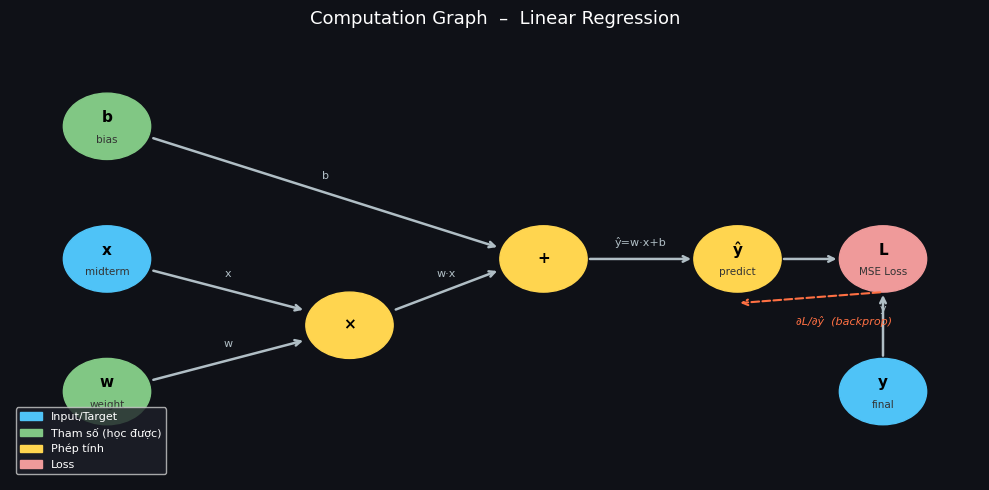

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')

# --- Màu sắc ---
C_INPUT  = '#4FC3F7'   # xanh dương nhạt
C_PARAM  = '#81C784'   # xanh lá
C_OP     = '#FFD54F'   # vàng
C_LOSS   = '#EF9A9A'   # đỏ nhạt
C_ARROW  = '#B0BEC5'
TXT      = 'white'

def draw_node(ax, x, y, label, sublabel='', color='#333', r=0.45):
    circle = plt.Circle((x, y), r, color=color, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y + (0.12 if sublabel else 0), label,
            ha='center', va='center', fontsize=11, fontweight='bold',
            color='black', zorder=4)
    if sublabel:
        ax.text(x, y - 0.18, sublabel, ha='center', va='center',
                fontsize=7.5, color='#333', zorder=4)

def draw_arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=C_ARROW, lw=1.8))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my+0.18, label, ha='center', fontsize=8,
                color=C_ARROW)

# --- Nodes ---
draw_node(ax, 1.0, 3.0, 'x',    'midterm',  C_INPUT)
draw_node(ax, 1.0, 1.2, 'w',    'weight',   C_PARAM)
draw_node(ax, 3.5, 2.1, '×',    '',         C_OP)
draw_node(ax, 1.0, 4.8, 'b',    'bias',     C_PARAM)
draw_node(ax, 5.5, 3.0, '+',    '',         C_OP)
draw_node(ax, 7.5, 3.0, 'ŷ',   'predict',  C_OP)
draw_node(ax, 9.0, 3.0, 'L',   'MSE Loss', C_LOSS)
draw_node(ax, 9.0, 1.2, 'y',   'final',    C_INPUT)

# --- Arrows ---
draw_arrow(ax, 1.45, 2.85, 3.05, 2.3,  'x')
draw_arrow(ax, 1.45, 1.35, 3.05, 1.9,  'w')
draw_arrow(ax, 3.95, 2.3,  5.05, 2.85, 'w·x')
draw_arrow(ax, 1.45, 4.65, 5.05, 3.15, 'b')
draw_arrow(ax, 5.95, 3.0,  7.05, 3.0,  'ŷ=w·x+b')
draw_arrow(ax, 7.95, 3.0,  8.55, 3.0,  '')
draw_arrow(ax, 9.0,  1.65, 9.0,  2.55, 'y')

# --- Gradient ngược ---
ax.annotate('', xy=(7.5, 2.4), xytext=(9.0, 2.55),
            arrowprops=dict(arrowstyle='->', color='#FF7043',
                            lw=1.5, linestyle='dashed'))
ax.text(8.1, 2.1, '∂L/∂ŷ  (backprop)', fontsize=8,
        color='#FF7043', style='italic')

ax.set_title('Computation Graph  –  Linear Regression',
             color='white', fontsize=13, pad=10)

# Legend
leg = [mpatches.Patch(color=C_INPUT, label='Input/Target'),
       mpatches.Patch(color=C_PARAM, label='Tham số (học được)'),
       mpatches.Patch(color=C_OP,    label='Phép tính'),
       mpatches.Patch(color=C_LOSS,  label='Loss')]
ax.legend(handles=leg, loc='lower left', fontsize=8,
          facecolor='#1e2029', labelcolor='white', framealpha=0.8)

plt.tight_layout()
plt.show()

## 5. Huấn luyện mô hình

In [8]:
NUM_EPOCHS = 500
losses = []

for epoch in range(NUM_EPOCHS):
    # Forward pass
    y_pred = model(X_tensor)
    loss   = criterion(y_pred, y_tensor)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1:>4}/{NUM_EPOCHS}]  "
              f"Loss: {loss.item():.4f}  "
              f"w={model.weight.item():.4f}  "
              f"b={model.bias.item():.4f}")

w_final = model.weight.item()
b_final = model.bias.item()
print(f"\n✅ Công thức học được:  final = {w_final:.4f} × midterm + ({b_final:.4f})")

Epoch [ 100/500]  Loss: 0.6620  w=1.0410  b=0.3899
Epoch [ 200/500]  Loss: 0.2461  w=0.9470  b=1.0189
Epoch [ 300/500]  Loss: 0.0915  w=0.8896  b=1.4025
Epoch [ 400/500]  Loss: 0.0340  w=0.8547  b=1.6364
Epoch [ 500/500]  Loss: 0.0127  w=0.8334  b=1.7790

✅ Công thức học được:  final = 0.8334 × midterm + (1.7790)


## 6. Kết quả & Đồ thị

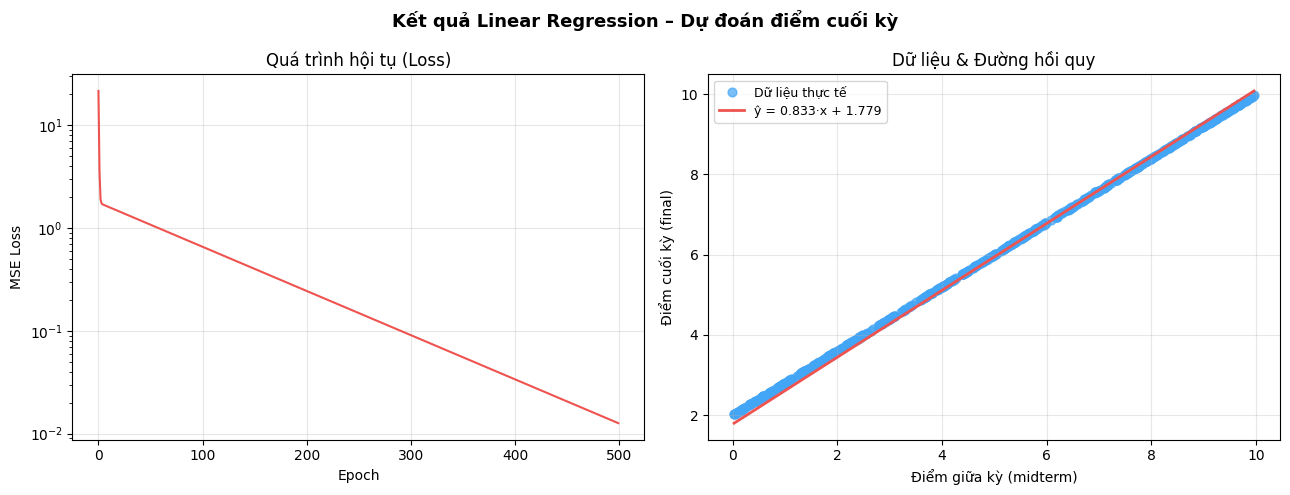

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Kết quả Linear Regression – Dự đoán điểm cuối kỳ',
             fontsize=13, fontweight='bold')

# --- Đồ thị 1: Loss ---
ax1 = axes[0]
ax1.plot(losses, color='#EF5350', linewidth=1.5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Quá trình hội tụ (Loss)')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# --- Đồ thị 2: Dữ liệu + đường hồi quy ---
ax2 = axes[1]
ax2.scatter(X, y, color='#42A5F5', alpha=0.7, s=40, label='Dữ liệu thực tế')

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
with torch.no_grad():
    y_line = model(torch.from_numpy(x_line.astype(np.float32))).numpy()

ax2.plot(x_line, y_line, color='#EF5350', linewidth=2,
         label=f'ŷ = {w_final:.3f}·x + {b_final:.3f}')

ax2.set_xlabel('Điểm giữa kỳ (midterm)')
ax2.set_ylabel('Điểm cuối kỳ (final)')
ax2.set_title('Dữ liệu & Đường hồi quy')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Đánh giá mô hình

In [10]:
with torch.no_grad():
    y_hat = model(X_tensor).numpy().flatten()

y_true = y.flatten()

mse  = np.mean((y_hat - y_true) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_hat - y_true))
ss_res = np.sum((y_true - y_hat) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2   = 1 - ss_res / ss_tot

print("=" * 38)
print("        Đánh giá mô hình")
print("=" * 38)
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")
print("=" * 38)
print(f"\n📐 Công thức:  final = {w_final:.4f} × midterm + ({b_final:.4f})")

        Đánh giá mô hình
  MSE  : 0.0125
  RMSE : 0.1119
  MAE  : 0.0935
  R²   : 0.9977

📐 Công thức:  final = 0.8334 × midterm + (1.7790)


## 8. Dự đoán điểm mới

In [11]:
def predict(midterm_score):
    x_new = torch.tensor([[float(midterm_score)]])
    with torch.no_grad():
        result = model(x_new).item()
    return result

# Thử dự đoán
test_scores = [3.0, 5.0, 7.5, 9.0]
print(f"{'Giữa kỳ':>10} │ {'Dự đoán cuối kỳ':>15}")
print("-" * 28)
for s in test_scores:
    print(f"{s:>10.1f} │ {predict(s):>15.2f}")

   Giữa kỳ │ Dự đoán cuối kỳ
----------------------------
       3.0 │            4.28
       5.0 │            5.95
       7.5 │            8.03
       9.0 │            9.28
